#### Random Forest ####

In [297]:
# import Libraries:
import pandas as pd

In [298]:
# read dataset:
dataset = pd.read_csv('50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [299]:
# Categorical column convert into numerical:
dataset = pd.get_dummies(dataset,drop_first=True)
dataset.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [300]:
# Split input and output columns:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [301]:
independent = dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [302]:
dependent = dataset[['Profit']]

In [303]:
# Split Train and test data:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size=0.30,random_state=0)

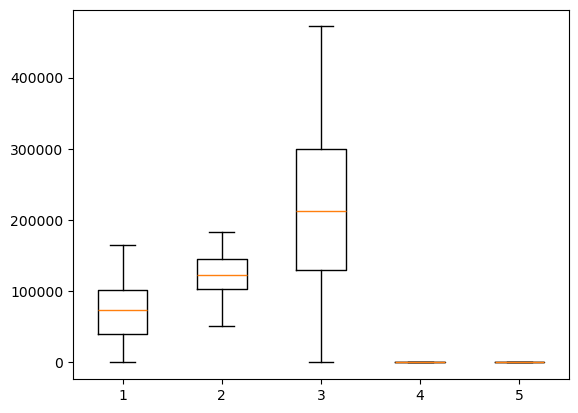

In [304]:
# if standardisation need do it here:
import matplotlib.pyplot as plt
plt.boxplot(independent)
plt.show()
# To check the extream value is there or not.

In [305]:
# model selection:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(random_state=0)
regressor

RandomForestRegressor(random_state=0)

In [306]:
# train the model:
regressor.fit(x_train,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=0)

In [307]:
# model tran prediction:
y_train_pred = regressor.predict(x_train)
y_train_pred

array([155392.3662, 137693.8313,  53496.6965,  39478.732 , 103535.2867,
       131701.2603,  99728.1116,  99503.6999, 123411.7828,  71734.5332,
       114966.2026,  69213.6924, 145187.6406, 133902.9641, 105207.4891,
       160859.9887, 126438.1578,  78407.2884,  28780.6499, 188575.4963,
       137855.6759,  87805.1371, 114761.4369, 152014.9541, 108359.4686,
        85091.6859, 116903.7814, 126639.1053, 148122.2926,  81821.5926,
        51862.9908, 173558.9512, 188601.73  ,  39874.2202,  67922.5557])

In [308]:
# evaluate the model training :
from sklearn.metrics import r2_score
train_r2_score = r2_score(y_train,y_train_pred) 
train_r2_score

0.988166397467361

In [309]:
# Model is ready going to test:
y_test_pred = regressor.predict(x_test)
y_test_pred

array([104131.3085, 134767.7027, 136940.3837,  79251.8251, 182860.3155,
       115810.3632,  69942.9352, 100347.8112, 114842.7638, 167117.7177,
       101048.768 ,  89843.4912, 117257.0921,  91658.5201, 130868.7268])

In [310]:
# r2 :
test_r2_score = r2_score(y_test,y_test_pred)
test_r2_score

0.9460043548938504

In [311]:
print('train_r2_score:',train_r2_score)
print('test_r2_score:', test_r2_score)

train_r2_score: 0.988166397467361
test_r2_score: 0.9460043548938504


In [312]:
train_r2_score-test_r2_score

0.04216204257351064

##'''R2 train is high. so, it learned well.
r2 test is also good.
so, model is acceptable. Random forest is reduce overfiting as compared to decision tree'''##

# Tuning the hyper parameter:
1. base model --->n_estiater=100,random_state=0 ---->r2 train=0.988166397467361,r2_test=0.9460043548938504,gap=0.04216204257351064---good
2. Model-1------->n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42-------->train_r2_score: 0.7863288501738208,test_r2_score: 0.660900233368445,gap=0.12542861680537587--poor model(underfitting)



In [315]:
# Create name or file for model:
file_name = 'Final_Random_Forest_regression_model.sav'

In [316]:
# write the model dump the model:
import pickle
pickle.dump(regressor,open(file_name,'wb'))

In [317]:
# load the model:
loaded_model = pickle.load(open('Final_Random_Forest_regression_model.sav','rb'))
loaded_model

RandomForestRegressor(random_state=0)

In [318]:
# final check:
result = loaded_model.predict([[1234,345,4565,1,0]])
result

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([50022.5385])